The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:pandapower.convert_format:These dtypes could not be corrected: {'gen': ['id_q_capability_characteristic'], 'shunt': ['id_characteristic_table']}


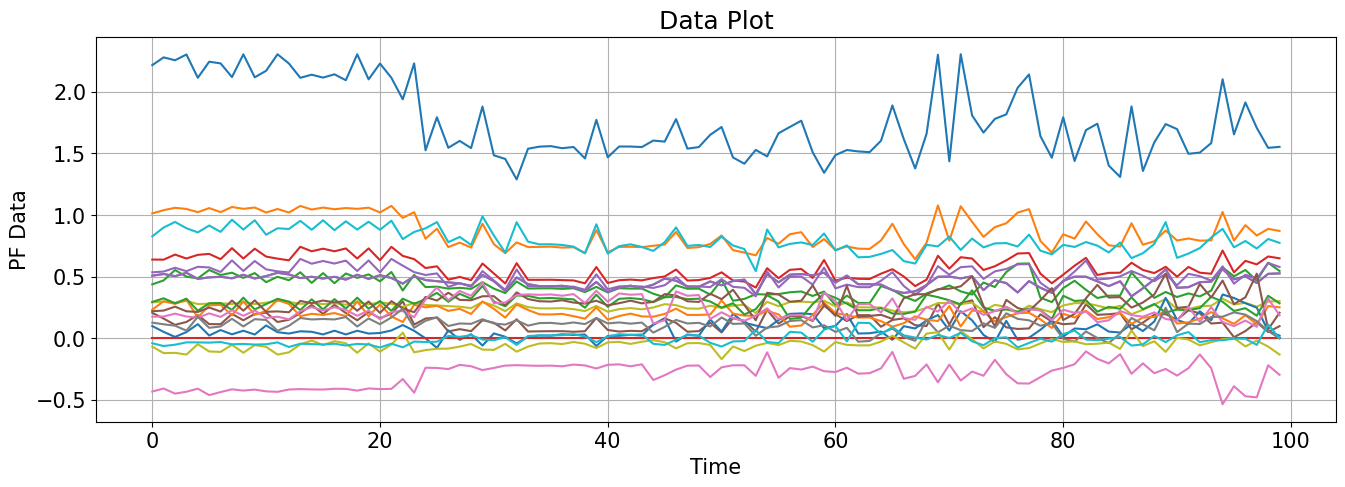

In [135]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.graph as graph
import lib.threshold as threshold
import lib.residual as resd
import lib.subBase as subBase
import lib.utils as utils
import lib.ac_se_fdia as ac_se_fdia
from skimage.filters import threshold_li
import pandas as pd
import lib.cycle_space as csp
import tqdm
from scipy.stats import chi2
from lib.read_ac_pf_csv import read_ac_power_flow_data
from scipy.linalg import qr
import pandapower as pp
import pandapower.networks as nw

mode= "AC" # DC
powerID= 14
IEEENames= ["IEEE 14", "IEEE 30", "IEEE 57", "IEEE 118"]
case_map = {14: nw.case14, 30: nw.case30, 57: nw.case57, 118: nw.case118}
net = case_map[powerID]()
outPutFile= False
datasource= "open" #open, matpower
# Load MATLAB file
opensource_file= f"C:/Users/30678/Desktop/large_files/ac_power_flow_data/pglib_opf_case{powerID}_ieee.csv"
matpower_file= f'matpower/test_data/{mode}_case{powerID}_.mat' #14, 118, 57, 30
Chenhan_file= f"data/ac/results{powerID}_AC.xlsx"
DC_file= f'data/paper_2/results{powerID}.xlsx' # DC
#
pfData, phaseData, H, A, qfData, resistance, voltage, reactance= ioFile.read_mat_power(matpower_file, normalize= False)

if datasource=="open":
    voltage, phaseData, pfData, pfDataT, qfData, qfDataT = \
        read_ac_power_flow_data(opensource_file, maxLen= 1000)
# pfData = np.vstack([np.zeros((1, pfData.shape[1])), pfData[1:, :]-pfData[:-1, :]])
pfDataDc, _=ioFile.read_excel_power(DC_file, id1= 0, id2= 0)
#
noZeroBranches= np.nonzero(np.abs(H).sum(axis= 0)!=0)
H= H[:, noZeroBranches].squeeze()
A= A[:, noZeroBranches].squeeze()
param= np.sum(np.abs(H), axis= 1, keepdims= True)/2
m= H.shape[0]
n= H.shape[1]
rankH= n-1
stdOfNoise= 1e-3
numTrain= m
#
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noiseE= noiseVector*stdOfNoise
pfDataE= pfData.copy()+noiseE
pfDataTrain= pfData[:m, :]
#
pfDataBus= powerfun.node_power_from_branch_ends(A, pfData.T, pfDataT.T).T
qfDataBus= powerfun.node_power_from_branch_ends(A, qfData.T, qfDataT.T).T
#
plotTimeSeries= True
if plotTimeSeries:
    plt.figure(figsize=(16, 5))
    for i in range(m):
        plt.plot(pfData[0:100, i], label=i)
    # plt.yscale("log")
    plt.title('Data Plot')
    plt.xlabel('Time')
    plt.ylabel('PF Data')
    plt.grid(True)
    plt.show()

In [137]:
timIdx= 5
# Count the number of lines
num_lines = len(net.line)

# Count the number of transformers
num_trafos = len(net.trafo)

print(num_lines, num_trafos)
# Build some synthetic measurements from a power flow result for demo
pp.runpp(net)
# Use a subset as "measurements"
bus_inj = []
for b in range(A.shape[1]):
    p =  float(pfDataBus[timIdx][b])*100
    q =  float(qfDataBus[timIdx][b])*100
    bus_inj.append([b, p, q])
branch = []
transformers= []
original_power_flows= [(int(A[i].argmax()), int(A[i].argmin())) for i in range(A.shape[0])]
linkMapping= ac_se_fdia.map_branches_to_pandapower(net, original_power_flows)
# For a few lines, take from-end flows
for line_idx in range(A.shape[0]):
    newIdx= linkMapping[line_idx]["index"]
    p_from = float(pfData[timIdx][newIdx])
    q_from = float(qfData[timIdx][newIdx])
    if linkMapping[line_idx]["type"]== "line":
        # no to-end provided in this quick demo
        branch.append([newIdx, 100*p_from, 100*q_from, None, None])
    else:
        transformers.append([newIdx, 100*p_from, 100*q_from, None, None])

statePred = ac_se_fdia.estimate_state(
    net,
    bus_injections=np.array(bus_inj, dtype=float),
    branch_flows=np.array(branch, dtype=object),
    transformers=np.array(transformers, dtype=object),
    std_p= 0,
    std_q= 0,
    init="results")
print(statePred["converged"])
print(statePred["iterations"])
print(statePred["va_degree"])
# print(statePred["vm_pu"])
print(phaseData[timIdx]*180/np.pi)

# phaseData[timIdx]= statePred["va_degree"]/180*np.pi

15 5


DEBUG:pandapower.estimation.state_estimation:State Estimation successful (21 iterations)


True
-1
[  0.          -4.98258915 -12.72509995 -10.3129011   -8.77385391
 -14.22094648 -13.35962738 -13.35962738 -14.93852131 -15.09728848
 -14.79062205 -15.07558454 -15.15627635 -16.03364455]
[-1.93865700e-28 -7.32366095e+00 -1.37359659e+01 -1.42528374e+01
 -1.29307832e+01 -2.54853412e+01 -2.01280667e+01 -2.01280667e+01
 -2.31303315e+01 -2.43023606e+01 -2.52359325e+01 -2.90363122e+01
 -2.73588240e+01 -2.58886956e+01]


In [138]:
# valide AC power flow
pfDataR= pfData*0
for branchId in range(pfData.shape[1]):
    BId= -1/reactance[branchId]
    busI= np.argmin(A[branchId, :])
    busJ= np.argmax(A[branchId, :])
    resistanceId= resistance[branchId]
    VI= voltage[:, busI]
    VJ= voltage[:, busJ]
    thetaI= phaseData[:, busI]
    thetaJ= phaseData[:, busJ]
    acData= pfData[:, branchId]
    acQData= qfData[:, branchId]
    acInfP= VI*VJ*(resistanceId*np.cos(thetaI-thetaJ)-BId*np.sin(thetaI-thetaJ))-VI*VI*resistanceId
    # acInfP= acInfP/(VI*VJ)
    pfDataR[:, branchId]= acInfP
    pass
# pfData= pfDataR
branchId= 7
timeId= [timIdx]
BId= -1/reactance[branchId] # X
resistanceId= resistance[branchId]
busI= np.argmin(A[branchId, :])
busJ= np.argmax(A[branchId, :])
VI= voltage[timeId, busI]
VJ= voltage[timeId, busJ]
thetaI= phaseData[timeId, busI]
thetaJ= phaseData[timeId, busJ]
acData= pfData[timeId, branchId]
acQData= qfData[timeId, branchId]
acInfP= VI*VJ*(resistanceId*np.cos(thetaI-thetaJ)-BId*np.sin(thetaI-thetaJ))-VI*VI*resistanceId
dcInfP= -VI*VJ*(thetaI-thetaJ)*BId
acInfQ= VI*VJ*(resistanceId*np.sin(thetaI-thetaJ)-BId*np.cos(thetaI-thetaJ))+VI*VI*BId
dcInfQ= -VI*VJ*BId*np.cos(thetaI-thetaJ)+VI*VI*BId
print()
print(acData)
print(acInfP)
print(dcInfP)
# print()
# print(acQData)
# print(acInfQ)
# print(dcInfQ)


[0.49348592]
[-0.48262923]
[-0.48347607]


In [139]:
#extract fundamental cycles from DC power flow
noiseVector= np.random.randn(pfDataDc.shape[0], pfDataDc.shape[1])
noiseE= noiseVector*1e-5
pfDataDcNoise= pfDataDc+noiseE
wholeRight= pfDataDcNoise[:numTrain, :].T.dot(pfDataDcNoise[:numTrain, :])
spaningTreeList, leftLinksSet= csp.get_spanning_tree(pfDataDcNoise[:numTrain, :], rankH, m)

cycleList, treeLinks= csp.get_cycle_and_tree(spaningTreeList, leftLinksSet, wholeRight, m)

_, cSpaceClean, _= resd.cycle_residual(pfData[:numTrain, :], rankH, m, pfData[numTrain:, :], cycleList)
NcSpaceClean= cSpaceClean@np.linalg.pinv(cSpaceClean.T@cSpaceClean)@cSpaceClean.T
for cycle in cycleList:
    print(len(cycle)-np.linalg.matrix_rank(H[list(cycle), :]), end=" ")
    pass
# cycleList= [{0, 1, 4}, {2, 4, 5, 6}, {3, 4, 6}, {8, 14, 7}, {6, 7, 9, 10, 14, 15, 17}, {18, 11, 12}, {10, 12, 15, 16, 17, 19}]
print()
print(cycleList)

c:\Users\30678\Desktop\code\python\23_1_power_grid_security\lib\parasLearn.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  predParas[item]= 1/line_parameters[0][i]


1 1 1 1 1 1 1 
[{0, 1, 4}, {2, 4, 5, 6}, {3, 4, 6}, {8, 14, 7}, {6, 7, 9, 10, 14, 15, 17}, {18, 11, 12}, {10, 12, 15, 16, 17, 19}]


In [140]:
print(len(cycleList))
plotXs= []
plotYs= []
for cycId in range(len(cycleList)):
     #IEEE 14 bus: 12, 13
    branchSelect= list(cycleList[cycId])
    # branchSelect= [70, 7, 9, 74, 75, 12, 76, 78, 21, 23, 32, 33, 36, 37, 38, 39, 40, 49, 50, 52, 54, 55, 58, 59, 60]
    subH= H[branchSelect, :]
    noZeroBus= np.nonzero(np.abs(subH).sum(axis= 0)!=0)
    subH= subH[:, noZeroBus].squeeze()
    U, S, V= np.linalg.svd(subH)
    pseudoNullstate= V[-2, :][:, None]
    pinvH= np.linalg.pinv(subH)
    U, S, V= np.linalg.svd(pinvH)
    pseudoNullMeas= subH@pseudoNullstate
    plotXs.append(np.max(param[branchSelect].T)/np.min(param[branchSelect].T))
    plotYs.append(np.linalg.norm(pseudoNullstate)/np.linalg.norm(pseudoNullMeas))
    if np.linalg.norm(pseudoNullstate)/np.linalg.norm(pseudoNullMeas)> 1.0:
        print(cycId)
        print(np.linalg.norm(pseudoNullstate)/np.linalg.norm(pseudoNullMeas))
        print(np.max(param[branchSelect].T)/np.min(param[branchSelect].T))
        print()


7


13.207789123723579
6 8


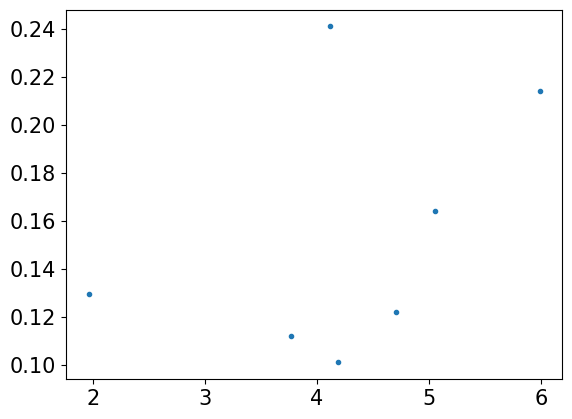

In [141]:
print(np.max(param)/np.min(param))
print(np.argmax(param), np.argmin(param))
plt.plot(plotXs, plotYs, ".")

DEBUG:matplotlib.ticker:vmin 0.21304096075176554 vmax 20.95577898745734
DEBUG:matplotlib.ticker:ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])
DEBUG:matplotlib.ticker:vmin 0.21304096075176554 vmax 20.95577898745734
DEBUG:matplotlib.ticker:ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03])
DEBUG:matplotlib.ticker:vmin 0.21304096075176554 vmax 20.95577898745734
DEBUG:matplotlib.ticker:ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])
DEBUG:matplotlib.ticker:vmin 0.21304096075176554 vmax 20.95577898745734
DEBUG:matplotlib.ticker:ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.

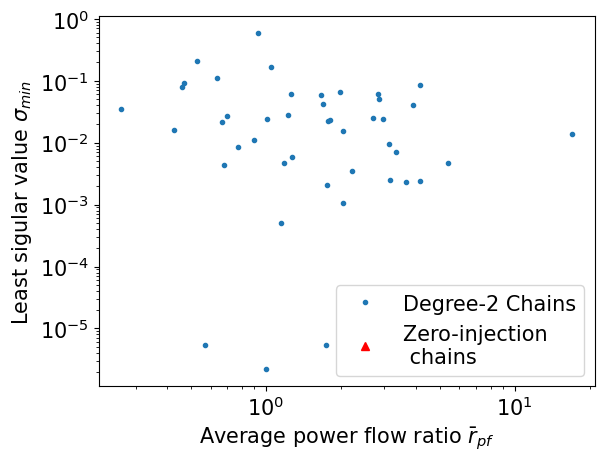

In [142]:
resultsy= []
resultsx= []
resultsys= []
resultsxs= []
for i in range(m):
    for j in range(i+1, m):
        if i in treeLinks:
            continue
        elif j in treeLinks:
            continue
        if np.sum(np.abs(A[[i], :]*A[[j], :]))<0.5:
            continue
        if np.sum(np.abs(A[[i], :]*A[[j], :]))>1.5:
            continue
        tmpPfData= pfDataE[:, [i,j]]
        cycleRight= tmpPfData.T@(tmpPfData)
        Val, Vt = np.linalg.eigh(cycleRight)
        Val= np.abs(np.real(Val))
        Val= Val/np.linalg.norm(Val)
        UT= np.abs(Vt[:, 0][:, None])
        minSingVal= Val[0]
        ratio= np.abs(np.mean(pfDataE[:, i]/pfDataE[:, j]))
        resultsx.append(ratio)
        resultsy.append(minSingVal)
        if minSingVal<1.5e-6:
            resultsxs.append(ratio)
            resultsys.append(minSingVal)
plt.plot(resultsx, resultsy, ".", label='Degree-2 Chains')
plt.plot(resultsxs, resultsys,  "^", c='red', label='Zero-injection \n chains')
plt.rcParams.update({'font.size': 15})
plt.ylabel(r"Least sigular value $\sigma_{min}$")
plt.xlabel(r"Average power flow ratio $\bar{r}_{pf}$")
plt.legend()
plt.xscale("log")
plt.yscale("log")

In [143]:
for k in range(5):
    countT= 0
    for i in range(len(cycleList)):
        for j in range(i+1, len(cycleList)):
            c1= cycleList[i]
            c2= cycleList[j]
            intersect= c1&c2
            left1= c1-intersect
            left2= c2-intersect
            if len(left1)<len(intersect):
                cycleList[j]= left1|left2
                countT+=(len(intersect)-len(left1))
            elif len(left2)<len(intersect):
                cycleList[i]= left1|left2
                countT+=(len(intersect)-len(left2))
    print(countT)
print(cycleList)
for cycle in cycleList:
    print(len(cycle)-np.linalg.matrix_rank(H[list(cycle), :]), end=" ")
    pass

2
0
0
0
0
[{0, 1, 4}, {2, 3, 5}, {3, 4, 6}, {8, 14, 7}, {17, 6, 8, 9, 10, 15}, {18, 11, 12}, {10, 12, 15, 16, 17, 19}]
1 1 1 1 1 1 1 

In [144]:
# tmpPdData= (H@simuX.T).T+noiseVector*1e-5

def get_indicators(tmpPfData):
    cycleRight= tmpPfData.T@(tmpPfData)
    Val, Vt = np.linalg.eigh(cycleRight)
    Val= np.abs(np.real(Val))
    Val= Val/np.linalg.norm(Val)
    UT= np.abs(Vt[:, 0][:, None])
    maxminPara= np.max(UT)/(np.min(UT)+1e-13)
    minSingVal= Val[0]
    return maxminPara, minSingVal
def reduce_cycle_branch():
    pass
ratiosStd= []
residuals= []
indicator= []
indicator2= []
errorDistributionDc= []
errorDistributionCyc= []
cycleLists= [list(i) for i in cycleList]
linkPairs= set()
cSpaces= []
for id, choosenCycle in enumerate(cycleLists):
    choosenCycle= list(choosenCycle)
    # print(choosenCycle)
    subH= H[choosenCycle, :]
    subH= subH[:, ~np.all(subH== 0, axis=0)]
    subA= A[choosenCycle, :]
    subA= subA[:, ~np.all(subA== 0, axis=0)]
    cyclePfData= pfDataTrain[:, choosenCycle]
    cycLen= cyclePfData.shape[1]
    subPara= param[choosenCycle]
    cycLen= cyclePfData.shape[1]
    squareRatio= np.zeros((cycLen, cycLen))+np.nan
    sameFlag= 0
    for i in range(cycLen): # remove linear dependent links
        for j in range(i):
            if cycLen>2:
                if get_indicators(cyclePfData[:, [i, j]])[1]<1e-5: 
                    sameFlag= 1
                    linkPairs.add((choosenCycle[i], choosenCycle[j]))
                    # print("ij:", i, " ", j)
                    # print("ij:", choosenCycle[i], " ", choosenCycle[j])
    _, _, pivot = qr(cyclePfData, pivoting=True)
    maxminPara, minSingVal= get_indicators(cyclePfData)
    cycleRight= cyclePfData.T@(cyclePfData)
    Val, Vt = np.linalg.eigh(cycleRight)
    Val= np.abs(np.real(Val))
    Val= Val/np.linalg.norm(Val)
    indicator.append(Val[0])
    indicator2.append(Val[0]/Val[1])
    # print()
    UT= Vt[:, 0][:, None]
    tmpi= 1
    while cycLen>2 and minSingVal<1e-6:
        tmpi+=1
        minSingVal= Val[tmpi]
    UT= Vt[:, :tmpi]
    print(Val)
    # print(cyclePfData.shape)
    dcSpace= np.sign(UT)/subPara
    dcSpace= dcSpace/np.linalg.norm(dcSpace)
    errorDistributionDc.append(cyclePfData@dcSpace)
    errorDistributionCyc.append(cyclePfData@UT)
    # print(np.linalg.norm(dcSpace))
    # print(np.linalg.norm(UT))
    line_parameter= np.abs(1/UT[:, -1][:, None])
    ratio= (line_parameter/subPara)[:, 0]
    if tmpi and sameFlag==0:
        pass
        # print(choosenCycle)
        # print(minSingVal)
        # print("pivot,",pivot)
        # print(np.round(squareRatio, 2)-1)
        # print(Val)
        # print(np.std(ratio))
        # print(id)
        # print()
    # print(np.std(ratio))
    ratiosStd.append(1e-4+np.std(ratio))
    # print(sortedVal)
    # print(ratio)
    # print(Val)
    cSpaceT= UT
    cSpaces.append(cSpaceT)
    residuals.append(np.mean(np.abs(cyclePfData@cSpaceT)))

[3.79074900e-07 6.77417030e-04 9.99999771e-01]
[3.01622599e-06 3.59131920e-03 9.99993551e-01]
[1.53404136e-07 1.01417616e-03 9.99999486e-01]
[7.61034706e-17 6.67479668e-07 1.00000000e+00]
[2.92886229e-05 7.45205729e-05 1.46074167e-04 1.02660996e-03
 2.06765699e-03 9.99997322e-01]
[1.72635680e-05 9.17563148e-03 9.99957903e-01]
[8.64018760e-06 3.24741171e-04 8.83848201e-04 5.45557177e-03
 1.71535115e-02 9.99837540e-01]


In [145]:
import cvxpy as cp

b = np.ones(pfData.shape[0])
a = cp.Variable(pfData.shape[1])
pMax= np.max(np.linalg.norm(pfData, axis= 1))
# print(np.linalg.norm(pfData, axis= 1).shape)
prob = cp.Problem(cp.Minimize(cp.sum_squares(pfData @ a - b)),
                  [cp.norm(a, 2) <= pMax])
prob.solve()          # choose a solver like OSQP/ECOS/SCS if needed
acA = a.value
print(np.linalg.norm(acA))
print(np.linalg.norm(pfData@acA-1))

3.128916746792459
2.91409165868811


C:\Users\30678\AppData\Local\Temp\ipykernel_14672\3907045117.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


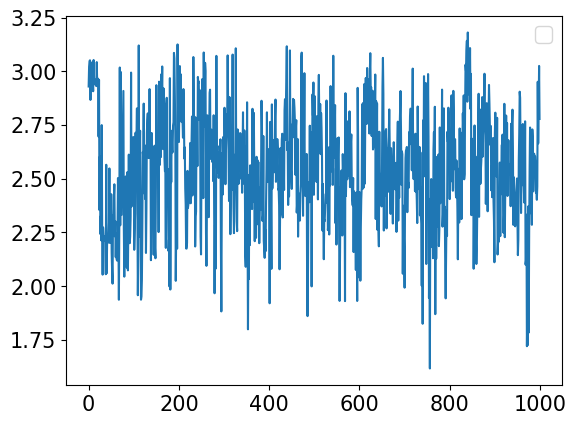

In [153]:
oneVector= np.ones(pfData.shape[0])
acA2= np.linalg.pinv(pfData) @ oneVector
# print((H.T@acA[:, None]).T)
# print(acA.shape)
# print(pfData@acA)
pfDataA= pfDataE*1.0
pfDataA[800:, :]= pfDataA[800:, :]+acA[None, :]*1e-1
detection= H.T@pfDataA.T
# plt.plot(np.linalg.norm(detection, axis= 0))
plt.plot(np.linalg.norm(pfDataA, axis= 1))
plt.legend()

C:\Users\30678\AppData\Local\Temp\ipykernel_14672\1506583696.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


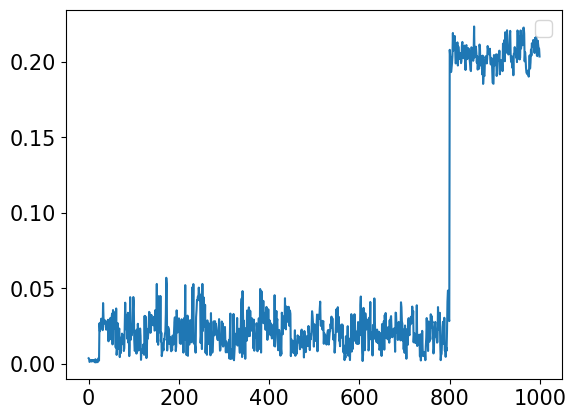

In [156]:
cycleRight= pfDataTrain.T@(pfDataTrain)
Val, Vt = np.linalg.eigh(cycleRight)
plt.plot(np.linalg.norm(pfDataA@Vt[:, :m-n-1], axis= 1))
# plt.plot((pfDataA@Vt[:, :m-n+2])[:, m-n])
plt.legend()

C:\Users\30678\AppData\Local\Temp\ipykernel_14672\2071067019.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


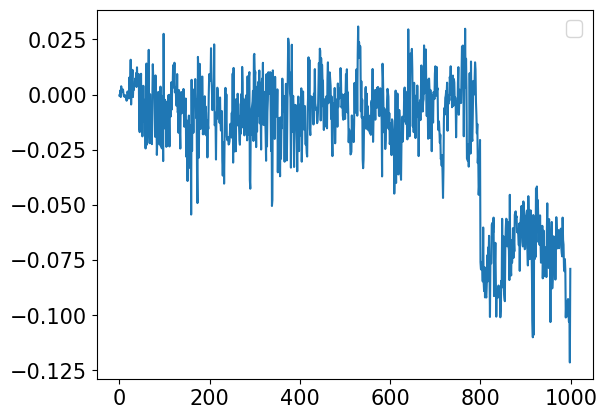

In [168]:
detections= []
for id, choosenCycle in enumerate(cycleLists):
    choosenCycle= list(choosenCycle)
    cSpaceT= cSpaces[id]
    cyclePfdata= pfDataA[:, choosenCycle]
    detection= cyclePfdata@cSpaceT
    for i in range(detection.shape[1]):
        detections.append(detection[:, i])

detectionsNp= np.stack(detections).squeeze()
plt.plot(detectionsNp.T[:, 9])
print()
# plt.plot(np.linalg.norm(detectionsNp.T, axis= 1))
plt.legend()

DEBUG:matplotlib.ticker:vmin 9.999999479583223e-10 vmax 1.000001092875822e-09
DEBUG:matplotlib.ticker:ticklocs array([1.e-11, 1.e-10, 1.e-09, 1.e-08, 1.e-07])
DEBUG:matplotlib.ticker:vmin 9.999999479583223e-10 vmax 1.000001092875822e-09
DEBUG:matplotlib.ticker:ticklocs array([2.e-11, 3.e-11, 4.e-11, 5.e-11, 6.e-11, 7.e-11, 8.e-11, 9.e-11,
       2.e-10, 3.e-10, 4.e-10, 5.e-10, 6.e-10, 7.e-10, 8.e-10, 9.e-10,
       2.e-09, 3.e-09, 4.e-09, 5.e-09, 6.e-09, 7.e-09, 8.e-09, 9.e-09,
       2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07])
DEBUG:matplotlib.ticker:vmin 9.999999479583223e-10 vmax 1.000001092875822e-09
DEBUG:matplotlib.ticker:ticklocs array([1.e-11, 1.e-10, 1.e-09, 1.e-08, 1.e-07])
DEBUG:matplotlib.ticker:vmin 9.999999479583223e-10 vmax 1.000001092875822e-09
DEBUG:matplotlib.ticker:ticklocs array([1.e-11, 1.e-10, 1.e-09, 1.e-08, 1.e-07])
DEBUG:matplotlib.ticker:vmin 9.999999479583223e-10 vmax 

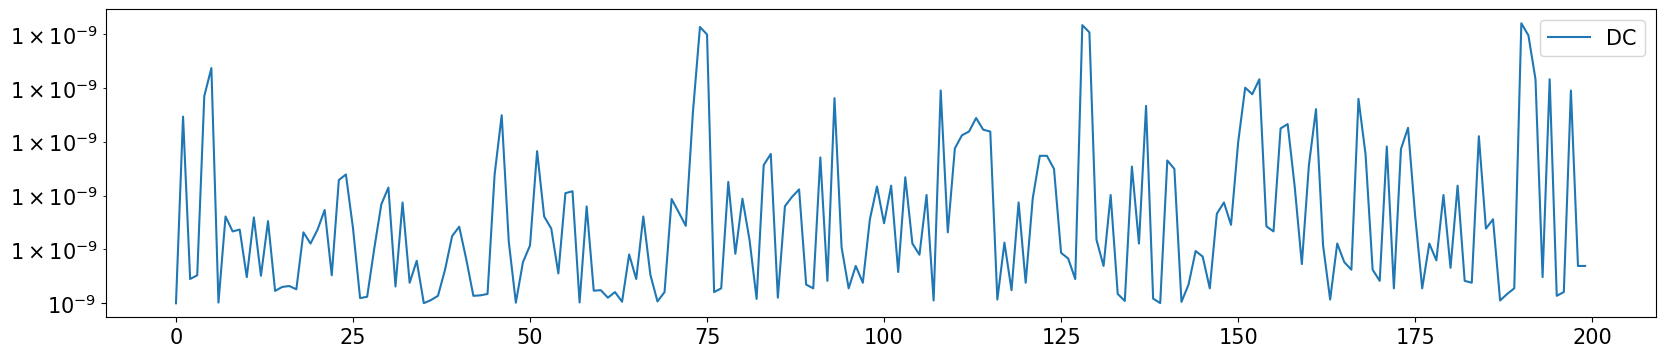

In [27]:
cId= 3
plt.figure(figsize=(20, 4))
# plt.plot(np.abs(errorDistributionDc[cId]))
plt.plot(1e-9+np.abs(errorDistributionCyc[cId]))
plt.legend(["DC", "CYC"])
plt.yscale("log")

[np.float64(0.0044623358292387545), np.float64(0.01673458795727515), np.float64(0.0028470011135650346), np.float64(720525708348.1458), np.float64(0.12262166024411901), np.float64(0.03688107673315049), np.float64(0.008129152446351848)]


DEBUG:matplotlib.ticker:vmin 0.0005422811954982895 vmax 3782792969862.2266
DEBUG:matplotlib.ticker:ticklocs array([1.e-10, 1.e-04, 1.e+02, 1.e+08, 1.e+14, 1.e+20])
DEBUG:matplotlib.ticker:vmin 0.0005422811954982895 vmax 3782792969862.2266
DEBUG:matplotlib.ticker:vmin 0.0005422811954982895 vmax 3782792969862.2266
DEBUG:matplotlib.ticker:ticklocs array([1.e-10, 1.e-04, 1.e+02, 1.e+08, 1.e+14, 1.e+20])
DEBUG:matplotlib.ticker:vmin 0.0005422811954982895 vmax 3782792969862.2266
DEBUG:matplotlib.ticker:ticklocs array([1.e-10, 1.e-04, 1.e+02, 1.e+08, 1.e+14, 1.e+20])
DEBUG:matplotlib.ticker:vmin 0.0005422811954982895 vmax 3782792969862.2266
DEBUG:matplotlib.ticker:vmin 0.0005422811954982895 vmax 3782792969862.2266
DEBUG:matplotlib.ticker:ticklocs array([1.e-10, 1.e-04, 1.e+02, 1.e+08, 1.e+14, 1.e+20])
DEBUG:matplotlib.ticker:vmin 0.0005422811954982895 vmax 3782792969862.2266
DEBUG:matplotlib.ticker:ticklocs array([1.e-10, 1.e-04, 1.e+02, 1.e+08, 1.e+14, 1.e+20])
DEBUG:matplotlib.ticker:vmin 0

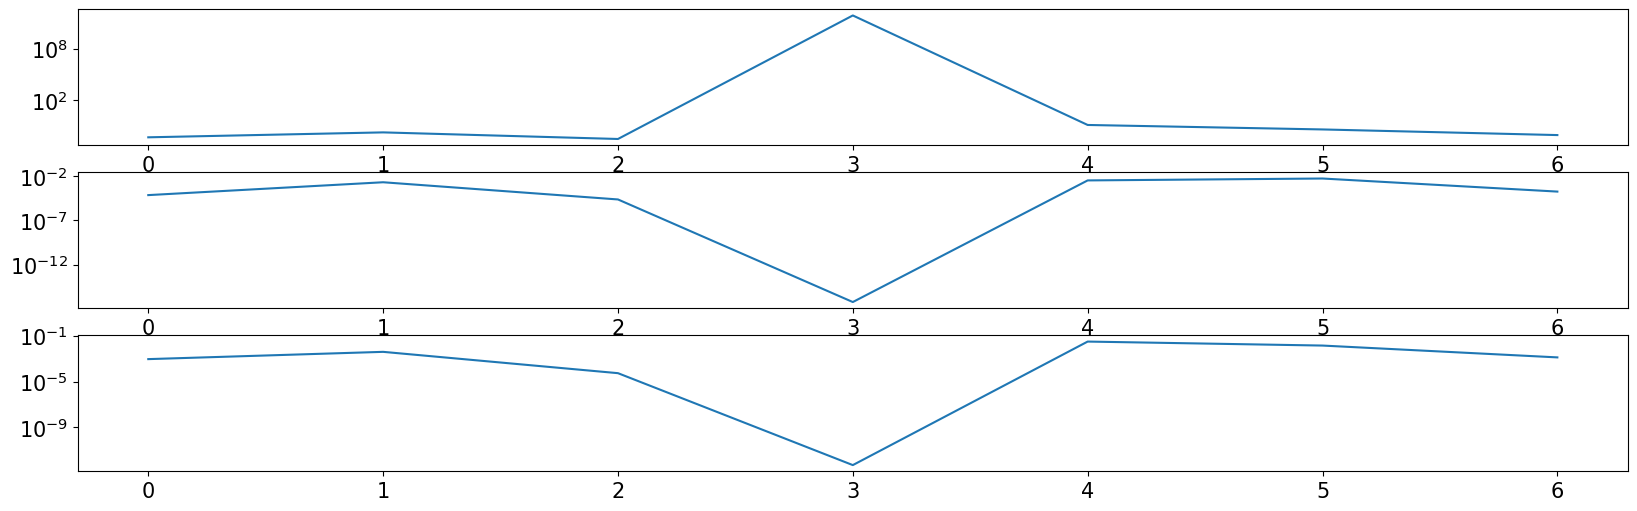

In [25]:
fig, axs = plt.subplots(3, 1, figsize=(20, 6))
print(ratiosStd) 
axs[0].plot(ratiosStd) 
axs[0].set_yscale("log") 
axs[1].plot(indicator) 
axs[1].set_yscale("log") 
axs[2].plot(indicator2) 
axs[2].set_yscale("log") 

In [9]:
linkPairsList= list(linkPairs)

print(linkPairsList)
pairID= 0
print(get_indicators(pfData[: ,[6, 9, 8]])[1])
print((pfData[:, 8]/pfData[:, 9])[0:20])
# print(reactance[11]/(reactance[10]+reactance[13])) # IEEE14
# print(reactance[8]/(reactance[14]+reactance[7])) # IEEE30


[(14, 8), (7, 8), (7, 14)]
0.0011191899952158408
[0.35243385 0.3309797  0.30407698 0.33920877 0.32242677 0.30762428
 0.32920765 0.28893154 0.33301596 0.28935592 0.34360817 0.33949964
 0.33248328 0.29287768 0.32383644 0.28925064 0.32476429 0.28670471
 0.33314811 0.29102814]


In [133]:
G, node_pair2id= graph.from_A_to_G(A[:, :])
G, _= graph.from_A_to_G(A[:, :])
G= G.to_undirected()
import matplotlib.cm as cm
import math


def visualize_cycles_min_overlap(G, node_pair2id, cycles, cycle_importance):
    plt.figure(figsize=(16, 10))
    # 1) link_id -> min importance among cycles containing it
    link_min = {}
    for cyc, imp in zip(cycles, cycle_importance):
        for lid in cyc:
            if lid in link_min:
                link_min[lid] = min(link_min[lid], imp)
            else:
                link_min[lid] = imp

    # 2) Build (u,v) -> link_id (include reversed pair for undirected convenience)
    edge2id = dict(node_pair2id)  # copy
    # Add reverse lookups if not present
    for (u, v), eid in list(node_pair2id.items()):
        if (v, u) not in edge2id:
            edge2id[(v, u)] = eid

    # 3) Map graph edges -> min importance (or None if no cycle)
    edge_vals = {}
    for u, v in G.edges():
        eid = edge2id.get((u, v), None)
        edge_vals[(u, v)] = link_min.get(eid, None)  # None means "not in any cycle"

    # 4) Prepare colormap over existing values
    vals = [v for v in edge_vals.values() if v is not None]
    if len(vals) == 0:
        vmin = 0.0
        vmax = 1.0
        norm = plt.Normalize(vmin, vmax)
    else:
        vmin, vmax = float(min(vals)), float(max(vals))
        # handle degenerate case (all equal) to avoid divide-by-zero
        if math.isclose(vmin, vmax):
            vmin -= 1e-12
            vmax += 1e-12
        norm = plt.Normalize(vmin, vmax)
    cmap = cm.get_cmap("Reds")

    # 5) Draw
    pos = nx.spring_layout(G) # seed
    nx.draw_networkx_nodes(G, pos, node_color="white", edgecolors="black", node_size=100)
    nx.draw_networkx_labels(G, pos, font_size=8)
    # Split edges by having value or not
    edges_in = [(e, edge_vals[e]) for e in edge_vals if edge_vals[e] is not None]
    edges_out = [e for e in edge_vals if edge_vals[e] is None]

    # Draw non-cycle edges (light gray, dashed)
    if edges_out:
        nx.draw_networkx_edges(
            G, pos, edgelist=edges_out, edge_color="lightgray", style="dashed", width=1.5
        )

    # Draw cycle edges colored by min-importance
    if edges_in:
        # Color and width by normalized importance
        colors = [cmap(norm(val)) for (_, val) in edges_in]
        widths = 1.5 # optional thickness
        nx.draw_networkx_edges(
            G, pos, edgelist=[e for (e, _) in edges_in],
            edge_color=colors, width=widths
        )
    nx.draw_networkx_edge_labels(G, pos, edge_labels=node_pair2id, font_size= 8, font_color= "black")

    # Colorbar
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm)
    # cbar.set_label("Cycle importance (min over overlaps)")
    # plt.title("Cycle Importance with Overlap = MIN")
    plt.axis("off")
    # plt.tight_layout()
    plt.show()

visualize_cycles_min_overlap(G, node_pair2id, cycleList, np.log10(ratiosStd))

NameError: name 'ratiosStd' is not defined

NameError: name 'attackPeriod' is not defined

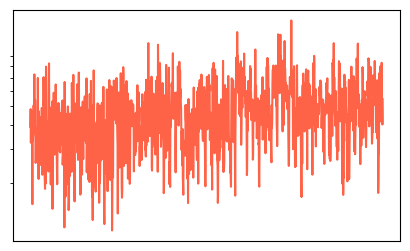

In [8]:
df = m-n+1  # degrees of freedom
confidence_level = 0.80
# Upper critical value (i.e., chi-square value such that P(X <= value) = 0.95)
thresholdChi= np.sqrt(chi2.ppf(confidence_level, df)*np.square(stdOfNoise))

errorC, cSpace, _= resd.cycle_residual(trainDataNp, rankH, m, testDataNp, cycleList= cycleList)
residualH, nullH= resd.svd_residual(trainDataNp, rankH, testDataNp)
residualT= resd.true_residual(H, m, testDataNp)

residualC= np.linalg.norm(errorC, axis= 0)

thresholdLi= threshold_li(residualC)
# residualC= np.square(residualC)/(stdOfNoise**2)
# residualT= np.square(residualT)/(stdOfNoise**2)
# residualH= np.square(residualH)/(stdOfNoise**2)
plt.figure(figsize=(5, 3))
fontsize= 15 
# smoothedresidualC = gaussian_filter1d(residualC, sigma= 10, axis=0, mode='reflect')
plt.plot(residualC, color= "tomato")
# plt.plot(smoothedresidualC)
# plt.plot([thresholdChi for _ in residualC] , "--", label = r"$\tau_{\chi}$")
# plt.plot([thresholdLi for _ in residualC] , "--", label = r"$\tau_{Li}$")
# plt.plot(residualCCp , label = "cycle space o", alpha= 0.6)
# plt.plot(residualH , label = "SVD-based detector", alpha= 0.6)
# plt.plot(residualHCp , label = "null space o", alpha= 0.6)
# plt.plot(residualT , label = "T space", alpha= 0.6)
# plt.plot(residualTCp , label = "T space o", alpha= 0.6)
# plt.xlabel("Samples", loc='right', fontsize= fontsize)
plt.yscale("log")
# plt.xticks([0, testDataNp.shape[0]], [0, testDataNp.shape[0]], fontsize= fontsize)
# plt.yticks(fontsize= fontsize)
plt.xticks([], [], fontsize= fontsize)
plt.yticks([], [], fontsize= fontsize)
# plt.ylim(0, 0.01)
# plt.ylabel("Reconstruction error", fontsize= fontsize) 
startIdx= np.nonzero(attackPeriod)[0][0]
endIdx= np.nonzero(attackPeriod)[0][-1]
plt.fill_between(range(startIdx, endIdx), np.min(residualC), np.max(residualC), alpha=0.4, color= "grey")
plt.axis("off")
plt.tight_layout()
# plt.legend(loc= 'lower left', fontsize= fontsize)
# startIdx= 0
# endIdx= numTrain
# plt.fill_between(range(startIdx, endIdx), 0, 0.2, alpha=0.4, color= "green")
if outPutFile:
    df = pd.read_excel(file_path, engine='openpyxl')
    for i in range(errorC.shape[0]):
        df[f"pf_{1+i}"]= errorC[i, :]
    df["reconstruction_error"]= np.linalg.norm(errorC, axis= 0)
    df.to_excel(out_path, index=False, engine='openpyxl')

In [110]:
stdOfNoises= []
trueDeltass= []
deltaDivides= []
varSums= []
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
for j in tqdm.tqdm(range(100)):
    stdOfNoise= 2e-2/(j+1)
    stdOfNoises.append(stdOfNoise)
    noiseE= noiseVector*stdOfNoise
    noisePfData= pfData.copy()+noiseE
    trainDataNp= noisePfData[:numTrain, :]
    testDataNp= noisePfData[numTrain:, :]
    errorC, cSpace, _= resd.cycle_residual(trainDataNp, rankH, m, testDataNp, cycleList= cycleList)

    signFun= 1*(cSpace>0)-1*(cSpace<0)
    absSignFun= np.abs(signFun)
    truecSpace= 1/param*signFun
    truecSpace= truecSpace/np.linalg.norm(truecSpace, axis= 0, keepdims= True)
    trueDeltas= 0
    deltaDelta= 0
    varSum= 0
    for i in range(cSpace.shape[1]):
        Zi= (pfData[:numTrain, :]*absSignFun[:, i])
        Ei= (noiseE[:numTrain, :]*absSignFun[:, i])
        Ni= truecSpace[:, i][:, None]
        Deltai= -np.linalg.pinv(Zi)@Ei@Ni
        varI= np.linalg.pinv(Zi.T@Zi)*np.square(stdOfNoise)*np.square(np.linalg.norm(Deltai))
        inferDelta= Deltai[:, 0]
        trueDelta= cSpace[:, i]-truecSpace[:, i]
        varSum+= np.sum(np.diag(varI))
        deltaDelta+= np.sum(np.square(inferDelta-trueDelta))
        trueDeltas+= np.sum(np.square(trueDelta))
        # break
    # deltaDivide= np.sqrt(deltaDelta/trueDeltas)
    trueDeltass.append(trueDeltas)
    deltaDivides.append(deltaDelta)
    varSums.append(varSum)
    # break

100%|██████████| 100/100 [00:42<00:00,  2.35it/s]


In [95]:
trueDeltasss= []
deltaDividess= []

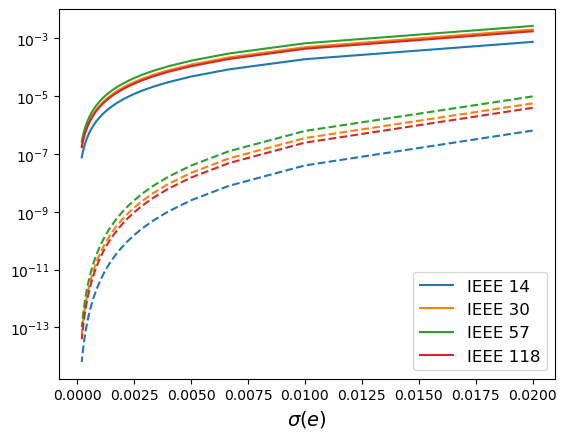

In [134]:
# plt.figure(figsize=(5, 3))
from matplotlib.lines import Line2D

fontSize= 14
tmpColorMap= plt.get_cmap('tab10')
fig, ax = plt.subplots()
for i in range(len(trueDeltasss)):
    ax.plot(stdOfNoises, trueDeltasss[i], color=tmpColorMap(i), label=f"{IEEENames[i]:}")#+r"$\sum\|\bar{\Delta}\|^2$")
    ax.plot(stdOfNoises, deltaDividess[i],linestyle='--', color=tmpColorMap(i), label= f"{IEEENames[i]:}")#+r"$\sum\|\Delta-\bar{\Delta}\|^2$")
# plt.plot(stdOfNoises, np.sqrt(varSums), label=r"$\sqrt{\sum\|Var(\Delta)\|^2}$")
plt.yscale("log")
ax.set_xlabel(r"$\sigma(e)$", fontsize= fontSize)
ax.tick_params(axis='both', labelsize=fontSize-4)
custom_lines = [Line2D([0], [0], color=tmpColorMap(i)) for i in range(len(trueDeltasss))]
plt.legend(custom_lines, IEEENames, fontsize=12)
# plt.legend(fontsize= fontsize-4)

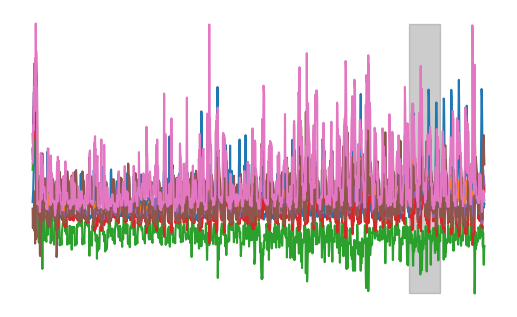

In [15]:
plt.figure(figsize=(5, 3))
plt.plot(testDataNp)
plt.xticks([], [], fontsize= fontsize)
plt.yticks([], [], fontsize= fontsize)
startIdx= np.nonzero(attackPeriod)[0][0]
endIdx= np.nonzero(attackPeriod)[0][-1]
plt.fill_between(range(startIdx, endIdx), np.min(testDataNp), np.max(testDataNp), alpha=0.4, color= "grey")
plt.axis("off")
plt.tight_layout()

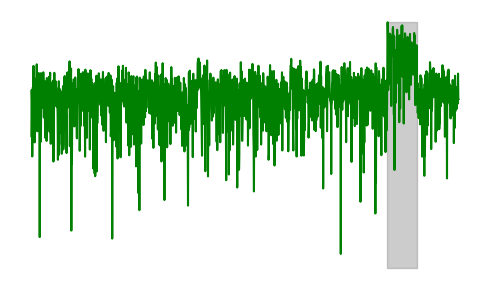

In [5]:
plt.figure(figsize=(5, 3))
# print(errorC.shape)
i= 2
colorMapTmp= ["purple", "orange", "green"]
plt.plot(errorC[i], color= colorMapTmp[i])
plt.yscale("log")
plt.xticks([], [], fontsize= fontsize)
plt.yticks([], [], fontsize= fontsize)
startIdx= np.nonzero(attackPeriod)[0][0]
endIdx= np.nonzero(attackPeriod)[0][-1]
plt.fill_between(range(startIdx, endIdx), np.min(errorC), np.max(errorC), alpha=0.4, color= "grey")
plt.axis("off")
plt.tight_layout()

In [45]:
plt.figure(figsize=(8, 4))
fontsize= 15
legends= [0.002, 0.005, 0.01, 0.02]

plt.rcParams.update({'font.size': fontsize})
for i, residualC in enumerate(residualCs):
    plt.plot(residualC , alpha= 1-i*0.2, label = f"std:{legends[i]}")
    plt.xlabel("Samples", fontsize= fontsize)
    plt.yscale("log")
startIdx= np.nonzero(attackPeriod)[0][0]
endIdx= np.nonzero(attackPeriod)[0][-1]
plt.fill_between(range(startIdx, endIdx), 0, 0.5, alpha=0.2, color= "grey")
plt.ylabel("Reconstruction error", fontsize= fontsize) 
plt.xticks([0, testDataNp.shape[0]], [0, testDataNp.shape[0]])
plt.legend(fontsize= fontsize, loc= 'upper left')

NameError: name 'residualCs' is not defined

<Figure size 800x400 with 0 Axes>

In [92]:
residualCs.append(residualC)

In [76]:
residualCs= []

In [7]:
from sklearn.metrics import precision_recall_curve, auc

mapPrecisionC= np.zeros((m-n+1, 100, 100))
mapPrecisionAll= np.zeros((1, 100, 100))
mapRecallC= np.zeros((m-n+1, 100, 100))
mapRecallAll= np.zeros((1, 100, 100))

originStdMeasurement= np.std((normalPfData-pfData))
LenofOriginAttack= np.sqrt(np.square(originStdMeasurement)*H.shape[0])
ratio= 0.1/LenofOriginAttack/100
ratio2= np.sqrt(0.0245/H.shape[0])
x_axis_label= []
lossCycle= []
lossSVD= []
confidence_level= 0.99
for i in tqdm.tqdm(range(100)):
    scale= (i)*ratio
    newAttackPfData= (normalPfData-pfData)*scale+normalPfData
    stdOfMeasurement= np.std((normalPfData-newAttackPfData))
    lenMeasurement= np.sqrt(np.square(stdOfMeasurement)*H.shape[0])
    x_axis_label.append(str(np.round(lenMeasurement, 3)))
    y_axis_label= []
    for j in range(100):
        noiseStd= ratio2*((j)/100)**3
        lenNoise= np.sqrt(np.square(noiseStd)*H.shape[0])
        y_axis_label.append(str(np.round(lenNoise, 3)))
        tmpMeasurement= (newAttackPfData+noiseVector*noiseStd)
        errorC, cSpace, wholeRight = resd.cycle_residual(tmpMeasurement[:numTrain, :], rankH, m, tmpMeasurement[numTrain:, :], cycleList)
        residualC= np.linalg.norm(errorC, axis= 0)
        if i==0:
            NcSpace= cSpace@np.linalg.inv(cSpace.T@cSpace)@cSpace.T
            lossCycle.append(np.linalg.norm(NcSpace- NcSpaceClean))
        precision, recall, _, _= threshold.li_threshold(residualC, attackPeriod)
        mapPrecisionAll[0, j, i]= precision
        mapRecallAll[0, j, i]= recall
        for k in range(m-n+1):
            precision, recall, _, _= threshold.li_threshold(errorC[k, :], attackPeriod)
            mapPrecisionC[k, j, i]= precision
            mapRecallC[k, j, i]= recall


100%|██████████| 100/100 [00:11<00:00,  8.69it/s]


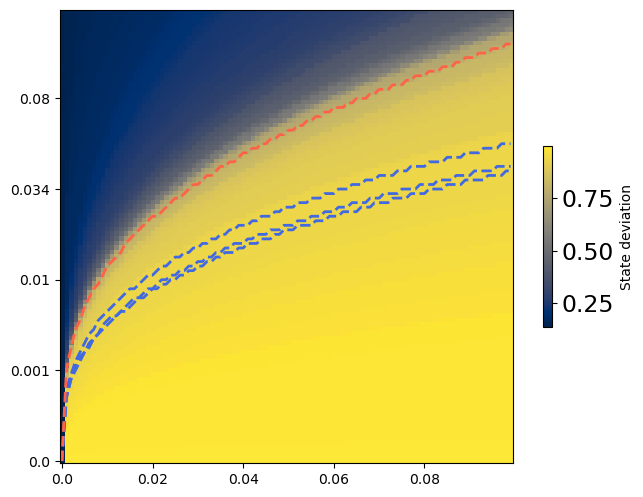

In [8]:
from matplotlib.colors import Normalize
plt.figure()
loadPrevious= False
fontsize= 17 #1 or 15
if loadPrevious:
    powerID= 30
    mapPrecisionC= np.load(f'log/{powerID}_mapPrecisionC.npy')
    mapRecallC= np.load(f'log/{powerID}_mapRecallC.npy')
    mapPrecisionAll= np.load(f'log/{powerID}_mapPrecisionAll.npy')
    mapRecallAll= np.load(f'log/{powerID}_mapRecallAll.npy')
np.save(f'log/{powerID}_mapPrecisionC.npy', mapPrecisionC)
np.save(f'log/{powerID}_mapRecallC.npy', mapRecallC)
np.save(f'log/{powerID}_mapPrecisionAll.npy', mapPrecisionAll)
np.save(f'log/{powerID}_mapRecallAll.npy', mapRecallAll)

f1C= 2*mapPrecisionC*mapRecallC/(mapRecallC+mapPrecisionC+1e-5)
f1All= 2*mapPrecisionAll*mapRecallAll/(mapRecallAll+mapPrecisionAll+1e-5)

heatToShow= f1All[0, :, :]# mapImpact, f1
plotHere= plt.imshow(heatToShow, cmap=  "cividis", norm=Normalize(vmin=np.min(heatToShow), vmax= np.max(heatToShow)), origin='lower')
f1Csum= (f1C[:, ...]>0.8).sum(axis= 1)
f1Allsum= (f1All[0, ...]>0.8).sum(axis= 0)
f1Csum[f1Csum>98.5]= 98
f1Allsum[f1Allsum>98.5]= 98
plt.plot(f1Csum.T, linestyle='dashed',  color= "royalblue", linewidth=2)
plt.plot(f1Allsum, linestyle='dashed', color= "tomato", linewidth=2)
colorbar =plt.colorbar(label= "State deviation", shrink=0.4)
colorbar.ax.tick_params(labelsize= fontsize)
plt.xticks(ticks= [i*20 for i in range(5)], labels= [x_axis_label[i*20] for i in range(5)])
plt.yticks(ticks= [i*20 for i in range(5)], labels= [y_axis_label[i*20] for i in range(5)])
plt.rcParams.update({'font.size': 1})# 15 or 1
# plt.ylabel("Magnitude of the noise vectors", fontsize= fontsize)
# plt.xlabel("Magnitude of the attack vectors", fontsize= fontsize)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import precision_recall_curve, auc

mapPrcC= np.zeros((m-n+1, 100, 100))
mapPrcAll= np.zeros((1, 100, 100))
mapPrcAllC= np.zeros((1, 100, 100))
mapPrcH= np.zeros((100, 100))
originStdMeasurement= np.std((normalPfData-pfData))
LenofOriginAttack= np.sqrt(np.square(originStdMeasurement)*H.shape[0])
ratio= 0.1/LenofOriginAttack/100
ratio2= np.sqrt(0.0245/H.shape[0])
x_axis_label= []
lossCycle= []
lossSVD= []
confidence_level= 0.99
for i in tqdm.tqdm(range(100)):
    scale= (i)*ratio
    newAttackPfData= (normalPfData-pfData)*scale+normalPfData
    stdOfMeasurement= np.std((normalPfData-newAttackPfData))
    lenMeasurement= np.sqrt(np.square(stdOfMeasurement)*H.shape[0])
    x_axis_label.append(str(np.round(lenMeasurement, 3)))
    y_axis_label= []
    for j in range(100):
        noiseStd= ratio2*((j)/100)**3
        lenNoise= np.sqrt(np.square(noiseStd)*H.shape[0])
        y_axis_label.append(str(np.round(lenNoise, 3)))
        tmpMeasurement= (newAttackPfData+noiseVector*noiseStd)
        errorC, cSpace, wholeRight = resd.cycle_residual(tmpMeasurement[:numTrain, :], rankH, m, tmpMeasurement[numTrain:, :], cycleList)
        residualC= np.linalg.norm(errorC, axis= 0)
        if i==0:
            NcSpace= cSpace@np.linalg.inv(cSpace.T@cSpace)@cSpace.T
            lossCycle.append(np.linalg.norm(NcSpace- NcSpaceClean))
        precision, recall, _ = precision_recall_curve(attackPeriod, residualC)
        pr_auc = auc(recall, precision)
        mapPrcAll[0, j,i]= pr_auc
        for k in range(m-n+1):
            precision, recall, _ = precision_recall_curve(attackPeriod, errorC[k, :])
            pr_auc = auc(recall, precision)
            mapPrcC[k, j,i]= pr_auc
            pass

100%|██████████| 100/100 [00:15<00:00,  6.29it/s]


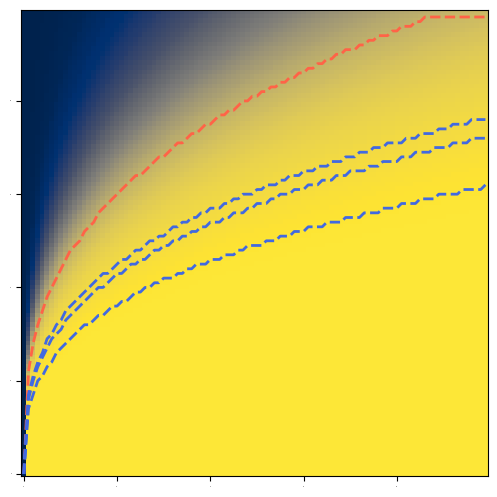

In [10]:
from matplotlib.colors import Normalize
powerID= 14
loadPrevious= 0
fontsize= 17 #1 or 15
plt.figure()

PrcAll= (mapPrcAll[0, ...]>0.8).sum(axis= 0)
PrcAll[PrcAll>98.5]= 98
PrcC= (mapPrcC[:, ...]>0.8).sum(axis= 1)
PrcC[PrcC>98.5]= 98

if loadPrevious:
    mapPrcAll= np.load(f'log/{powerID}_mapPrcAll.npy')
heatToShow= mapPrcAll[0, ...]# 
plotHere= plt.imshow(heatToShow, cmap=  "cividis", norm=Normalize(vmin=np.min(heatToShow), vmax= np.max(heatToShow)), origin='lower')
np.save(f'log/{powerID}_mapPrcAll.npy', mapPrcAll)
if loadPrevious:
    PrcAll= np.load(f'log/{powerID}_PrcAll.npy')
plt.plot(PrcAll, linestyle='dashed',  color= "tomato", linewidth=2)
np.save(f'log/{powerID}_PrcAll.npy', PrcAll)
if loadPrevious:
    PrcC= np.load(f'log/{powerID}_PrcC.npy')
plt.plot(PrcC.T, linestyle='dashed',  color= "royalblue", linewidth=2)
np.save(f'log/{powerID}_PrcC.npy', PrcC)
# colorbar =plt.colorbar(label= "PR-AUC", shrink=0.4)
# colorbar.ax.tick_params(labelsize=fontsize)
# plt.xticks(ticks= [i*20 for i in range(5)], labels= [x_axis_label[i*20] for i in range(5)])
# plt.yticks(ticks= [i*20 for i in range(5)], labels= [y_axis_label[i*20] for i in range(5)])
plt.rcParams.update({'font.size': 1})
# plt.ylabel("Magnitude of the noise vectors", fontsize= fontsize)
# plt.xlabel("Magnitude of the attack vectors", fontsize= fontsize)
plt.tight_layout()
plt.show()

In [ ]:

colors= ["blue", "green", "purple", "pink"]
for i in range(len(lossCycles)):
    plt.plot(lossCycles[i], label= f"Cycle-based {IEEENames[i]}", color= colors[i])
    # plt.plot(lossSVDs[i], "--", label= f"SVD-based {IEEENames[i]}",  color= colors[i])
# plt.yscale("log")
plt.xticks(ticks= [0]+[19+i*20 for i in range(5)], labels= [0]+[y_axis_label[19+i*20] for i in range(5)])
plt.rcParams.update({'font.size': 15})
plt.xlabel("Magnitude of the noise vectors")
plt.ylabel("Projection matrix error")
plt.legend()
plt.tight_layout()

NameError: name 'lossCycles' is not defined

In [202]:
lossCycles.append(lossCycle)
lossSVDs.append(lossSVD)

In [185]:
lossCycles= []
lossSVDs= []

56
746


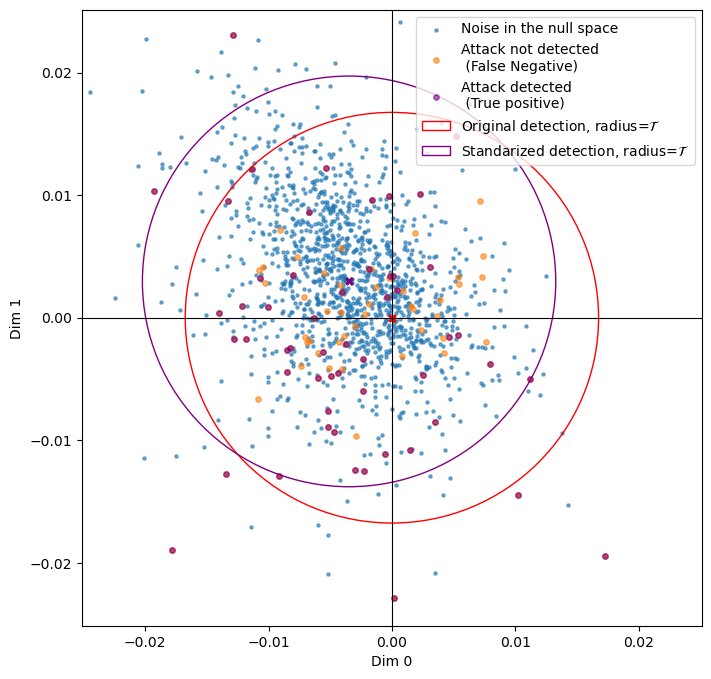

In [217]:
nullH2D= nullH[:, [6, 1]]# 6, 10, 11

tau= threshold_li(residualH)
limRange= tau*1.5
visul2D= nullH2D.T@pfDatanor.T
center2= nullH2D.T@(np.mean(pfDatanor, 0, keepdims= True).T)
center2= (center2[0], center2[1])
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(visul2D[0, attackPeriod==0], visul2D[1, attackPeriod==0], s= 5, alpha=0.6, label= "Noise in the null space")
attackDetc= residualH>tau
cross= np.sum(attackDetc*(attackPeriod>1e-5))
negcross= np.sum((1-attackDetc)*(1-attackPeriod>1e-5))
print(cross)
print(negcross)
ax.scatter(visul2D[0, attackPeriod>1e-5], visul2D[1, attackPeriod>1e-5], s= 15, alpha=0.6, label= "Attack not detected \n (False Negative)")

ax.scatter(visul2D[0, attackDetc*(attackPeriod>1e-5)], visul2D[1, attackDetc*(attackPeriod>1e-5)], s= 15, alpha=0.6,  color='purple', label= "Attack detected \n (True positive)")

circle1= plt.Circle((0, 0), radius= tau, color='red', fill=False, linewidth=1, label= "Original detection, radius=$\mathcal{T}$")
ax.add_patch(circle1)
circle2= plt.Circle(center2, radius= tau, color='purple', fill=False, linewidth=1, label= "Standarized detection, radius=$\mathcal{T}$")
ax.add_patch(circle2)
ax.scatter(0, 0, s= 40, alpha=1, color='red', marker= "X", linewidths= 0.01)
ax.scatter(center2[0], center2[1], s= 40, alpha=1, color='purple', marker= "X", linewidths= 0.01)
plt.xlabel("Dim 0")
plt.ylabel("Dim 1")
plt.axhline(0, color='black', linewidth=0.8)  # x-axis
plt.axvline(0, color='black', linewidth=0.8)  # y-axis
plt.xlim(-limRange, limRange)
plt.ylim(-limRange, limRange)
plt.legend()

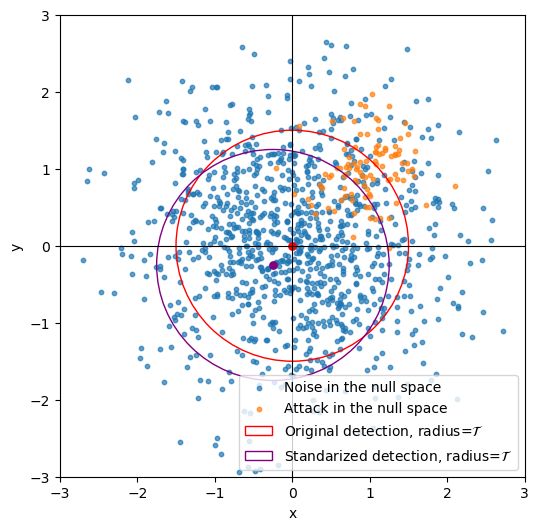

In [58]:
# Set random seed for reproducibility (optional)
np.random.seed(42)
biasXY= (1, 1)

# Sample 100 points from a Gaussian distribution with mean=0, variance=1
x = np.random.normal(loc=0.0, scale=1.0, size=1000)
y = np.random.normal(loc=0.0, scale=1.0, size=1000)

xA = np.random.normal(loc=0.0, scale=0.4, size=100)+biasXY[0]
yA = np.random.normal(loc=0.0, scale=0.4, size=100)+biasXY[1]

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s= 10, alpha=0.7, label= "Noise in the null space")
ax.scatter(xA, yA, s= 10, alpha=0.7, label= "Attack in the null space")
ax.scatter(0, 0, s= 40, alpha=1, color='red', marker= "o", linewidths= 0.01)
circle1= plt.Circle((0, 0), radius=1.5, color='red', fill=False, linewidth=1, label= "Original detection, radius=$\mathcal{T}$")
center2= (-biasXY[0]/4, -biasXY[1]/4)
ax.scatter(center2[0], center2[1], s= 40, alpha=1, color='purple', marker= "o", linewidths= 0.01)
circle2= plt.Circle(center2, radius=1.5, color='purple', fill=False, linewidth=1, label= "Standarized detection, radius=$\mathcal{T}$")
ax.add_patch(circle1)
ax.add_patch(circle2)
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.8)  # x-axis
plt.axvline(0, color='black', linewidth=0.8)  # y-axis

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.grid(False)
plt.legend()
plt.show()

num links
78
80
num links


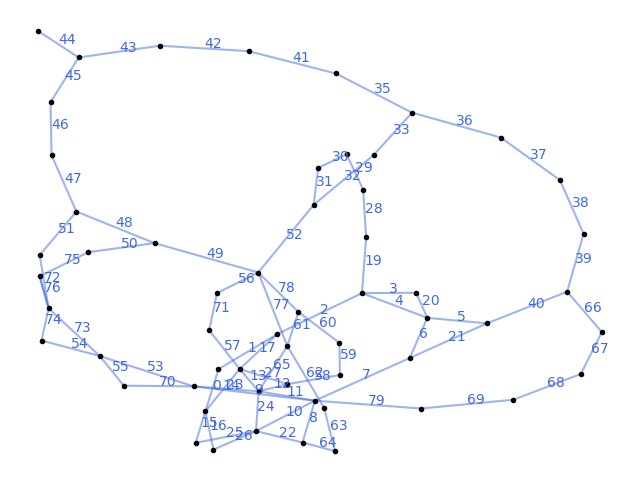

In [134]:
G, node_pair2id= graph.from_A_to_G(A[:, :])
G, _= graph.from_A_to_G(A[:, :])
print("num links")
print(G.number_of_edges())
print(m)
print("num links")
G= G.to_undirected()
biconnected_components = list(nx.biconnected_components(G))
largest_bcc = list(max(biconnected_components, key=len))
plotGraph.plot_spring_layout(G, label= False, label_edge= True, node_pair2id= node_pair2id)

In [69]:
linkPairsList= list(linkPairs)
print(linkPairsList)
pairID= 0
print(get_indicators(pfData[: ,list(linkPairsList[pairID])])[1])
print(np.mean(pfData[:,linkPairsList[pairID][0]]/pfData[:,linkPairsList[pairID][1]]))
# print(reactance[11]/(reactance[10]+reactance[13])) # IEEE14
# print(reactance[8]/(reactance[14]+reactance[7])) # IEEE30
#IEEE128: 2, 
#IEEE57: 7,
#IEEE30: 1,
#IEEE14: 1

[(93, 92), (126, 125)]
0.0
-1.0


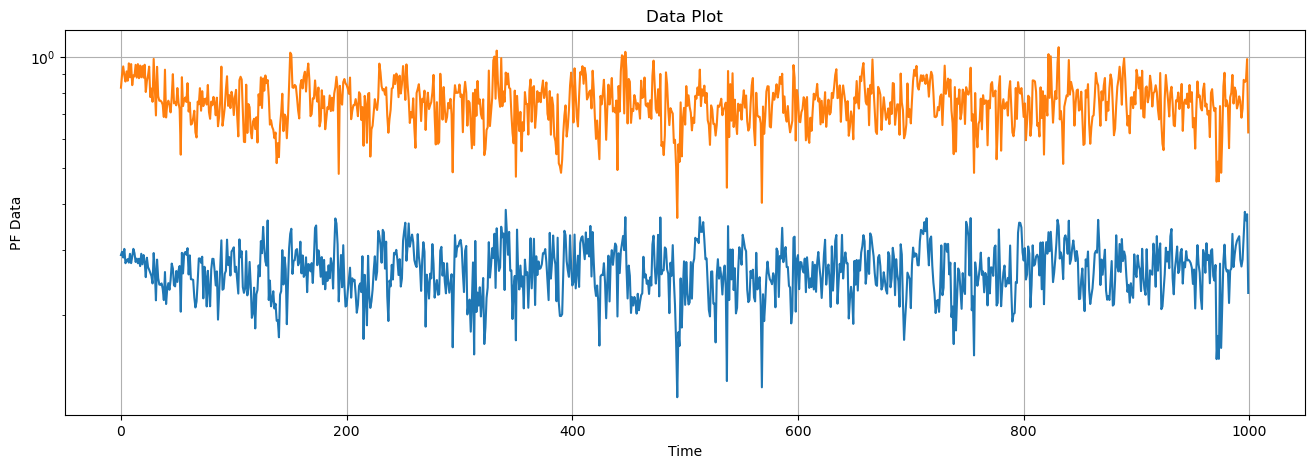

In [177]:
plotTimeSeries= True
if plotTimeSeries:
    plt.figure(figsize=(16, 5))
    for i in list([8, 9]):
        plt.plot(np.abs(pfData[:, i]), label=i)
    # plt.yscale("log")
    plt.title('Data Plot')
    plt.xlabel('Time')
    plt.ylabel('PF Data')
    plt.grid(True)
    plt.yscale("log")
    plt.show()